# House Price Prediction — Model Training Notebook

**Dataset:** House Price by Juhi Bhojani — https://www.kaggle.com/datasets/juhibhojani/house-price

**Goal:** Clean the raw listings data, engineer features, train and compare regression models, and export a deployable pipeline (`house_price.pkl`).

> Before running: download the dataset (see README) and place `house_prices.csv` inside `data/`.


## 2.1 Load & Inspect

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Zbook G6\Desktop\house-price-project\notebooks\data\house_prices.csv")
df.shape

(4000, 21)

In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,3 BHK Flat for sale,Nice property in a good locality with all amen...,46.4 Lac,4.635761e+06,Location_52,NaN,Under Construction,1 out of 6,Resale,...,West,Main Road,NaN,NaN,2.0,NaN,Power Of Attorney,NaN,NaN,NaN
1,1,4 BHK Flat for sale,Nice property in a good locality with all amen...,1.33 Cr,1.325054e+07,Location_62,NaN,Under Construction,1 out of 14,Resale,...,NaN,Not Available,NaN,3.0,3.0,NaN,Power Of Attorney,NaN,NaN,NaN
2,2,3 BHK Flat for sale,Nice property in a good locality with all amen...,1.31 Cr,1.314061e+07,Location_4,3473 sqft,Ready to Move,7 out of 23,New Property,...,North-East,Not Available,Society_252,2.0,0.0,0.0,NaN,NaN,NaN,NaN
3,3,3 BHK Flat for sale,Nice property in a good locality with all amen...,97.4 Lac,9.744803e+06,Location_1,2427 sqft,Under Construction,Ground out of 7,Resale,...,NaN,Pool,Society_216,2.0,1.0,0.0,Co-operative Society,902 sqft,NaN,NaN
4,4,1 BHK Flat for sale,Nice property in a good locality with all amen...,77.6 Lac,7.761386e+06,Location_14,1270 sqft,Ready to Move,10 out of 13,New Property,...,NaN,Pool,Society_284,1.0,0.0,NaN,Power Of Attorney,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              4000 non-null   int64  
 1   Title              4000 non-null   object 
 2   Description        4000 non-null   object 
 3   Amount(in rupees)  3964 non-null   object 
 4   Price (in rupees)  4000 non-null   float64
 5   location           3928 non-null   object 
 6   Carpet Area        3584 non-null   object 
 7   Status             4000 non-null   object 
 8   Floor              3821 non-null   object 
 9   Transaction        4000 non-null   object 
 10  Furnishing         3597 non-null   object 
 11  facing             3163 non-null   object 
 12  overlooking        4000 non-null   object 
 13  Society            2844 non-null   object 
 14  Bathroom           3813 non-null   float64
 15  Balcony            3397 non-null   float64
 16  Car Parking        2863 

In [6]:
df.describe(include="all")

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
count,4000.000000,4000,4000,3964,4.000000e+03,3928,3584,4000,3821,4000,...,3163,4000,2844,3813.000000,3397.000000,2863.000000,3209,1974,0.0,0.0
unique,NaN,4,1,984,NaN,79,2101,2,324,2,...,8,4,299,NaN,NaN,NaN,4,1438,NaN,NaN
top,NaN,2 BHK Flat for sale,Nice property in a good locality with all amen...,Call for Price,NaN,Location_59,1521 sqft,Ready to Move,Ground out of 1,New Property,...,North-East,Main Road,Society_250,NaN,NaN,NaN,Power Of Attorney,252 sqm,NaN,NaN
freq,NaN,1015,4000,80,NaN,70,6,2033,80,2023,...,429,1033,26,NaN,NaN,NaN,818,6,NaN,NaN
mean,1999.500000,NaN,NaN,NaN,1.076009e+07,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.592185,1.505446,1.009081,NaN,NaN,NaN,NaN
std,1154.844867,NaN,NaN,NaN,6.346192e+06,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.062927,1.124357,0.818156,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,1.136405e+06,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,999.750000,NaN,NaN,NaN,5.761093e+06,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,1999.500000,NaN,NaN,NaN,9.690308e+06,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.000000,2.000000,1.000000,NaN,NaN,NaN,NaN
75%,2999.250000,NaN,NaN,NaN,1.446847e+07,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.000000,3.000000,2.000000,NaN,NaN,NaN,NaN


In [7]:
missing = df.isna().mean().sort_values(ascending=False)
missing

Plot Area            1.00000
Dimensions           1.00000
Super Area           0.50650
Society              0.28900
Car Parking          0.28425
facing               0.20925
Ownership            0.19775
Balcony              0.15075
Carpet Area          0.10400
Furnishing           0.10075
Bathroom             0.04675
Floor                0.04475
location             0.01800
Amount(in rupees)    0.00900
Description          0.00000
Title                0.00000
Index                0.00000
Price (in rupees)    0.00000
overlooking          0.00000
Status               0.00000
Transaction          0.00000
dtype: float64

**Answer these before moving on:**
- How many rows and columns does the dataset have?
- Which columns are numeric vs text?
- Which columns have the most missing values, and could they be dropped or need imputation?

_(Fill in your answers here after running the cells above.)_


## 2.3 Cleaning & Feature Engineering

The dataset is messy on purpose. We handle, in order:
1. Price (`Amount(in rupees)`) — text like "42 Lac" / "1.2 Cr" → numeric INR
2. Area (`Carpet Area` / `Super Area`) — text like "1200 sqft" / "140 sqm" → numeric sqft
3. Floor (`Floor`) — text like "3 out of 10" → numeric floor number
4. Bathroom / Balcony / Car Parking — numeric, impute missing
5. High-cardinality categoricals (`location`, `Society`) — keep top-50, group rest as "other"
6. Drop useless columns
7. Remove price-per-sqft outliers


In [8]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(3884, 22)

In [9]:
import re

def parse_area(x):
    """Extract numeric area and normalise to sqft (1 sqm ~= 10.764 sqft)."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"[\d,.]+", x)
    if not match:
        return None
    value = float(match.group().replace(",", ""))
    if "sqm" in x:
        value *= 10.764
    return value

# Prefer Carpet Area, fall back to Super Area
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["Super Area"].apply(parse_area))
df = df.dropna(subset=["carpet_area_sqft"])
df["carpet_area_sqft"].describe()

count    3674.000000
mean     1932.494759
std       898.482444
min       398.268000
25%      1137.250000
50%      1929.500000
75%      2701.750000
max      3499.000000
Name: carpet_area_sqft, dtype: float64

In [10]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    match = re.search(r"-?\d+", x)
    return int(match.group()) if match else None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [11]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())
df["balcony"] = df["Balcony"].fillna(0)
df["car_parking"] = df["Car Parking"].fillna(0)

In [12]:
TOP_N = 50
top_locations = df["location"].value_counts().nlargest(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

df["location_grouped"].value_counts().head(10)

location_grouped
other          1122
Location_9       65
Location_59      65
Location_45      64
Location_65      60
Location_16      58
Location_8       58
Location_44      57
Location_58      57
Location_47      56
Name: count, dtype: int64

In [13]:
drop_cols = [c for c in ["Index", "Title", "Description", "Dimensions"] if c in df.columns]
# also drop columns that are mostly empty
mostly_empty = [c for c in df.columns if df[c].isna().mean() > 0.6]
drop_cols = list(set(drop_cols + mostly_empty))
df = df.drop(columns=drop_cols)
drop_cols

['Description', 'Dimensions', 'Index', 'Plot Area', 'Title']

In [14]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
df.shape

(3600, 23)

## 2.2 Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

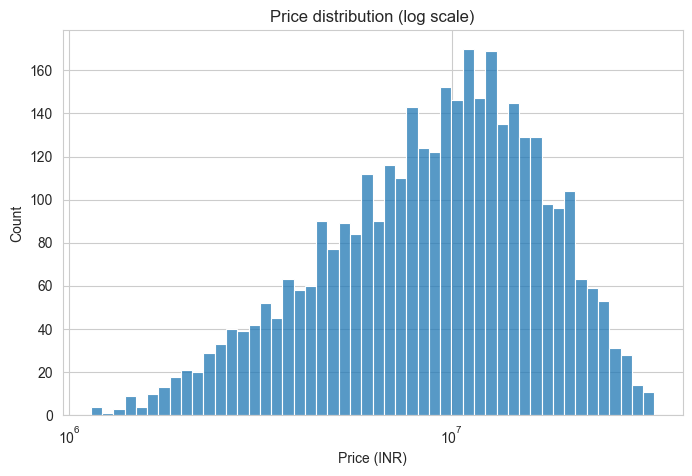

In [16]:
# Plot 1 — Distribution of price (log scale, since price is heavily skewed)
plt.figure(figsize=(8, 5))
sns.histplot(df["price_clean"], log_scale=True, bins=50)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

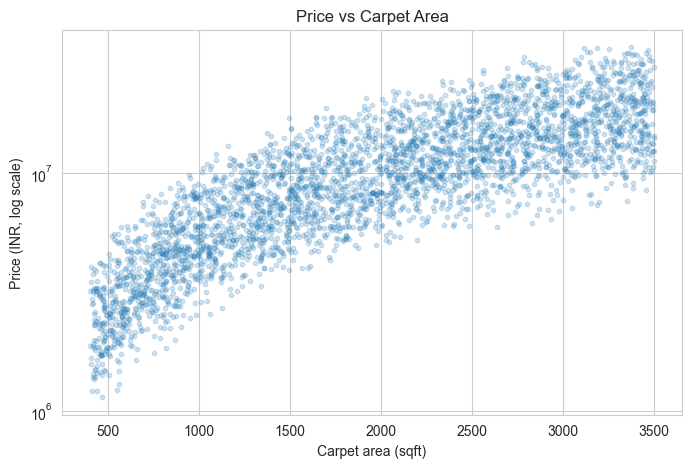

In [17]:
# Plot 2 — Price vs carpet area
plt.figure(figsize=(8, 5))
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.2, s=10)
plt.yscale("log")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (INR, log scale)")
plt.title("Price vs Carpet Area")
plt.show()

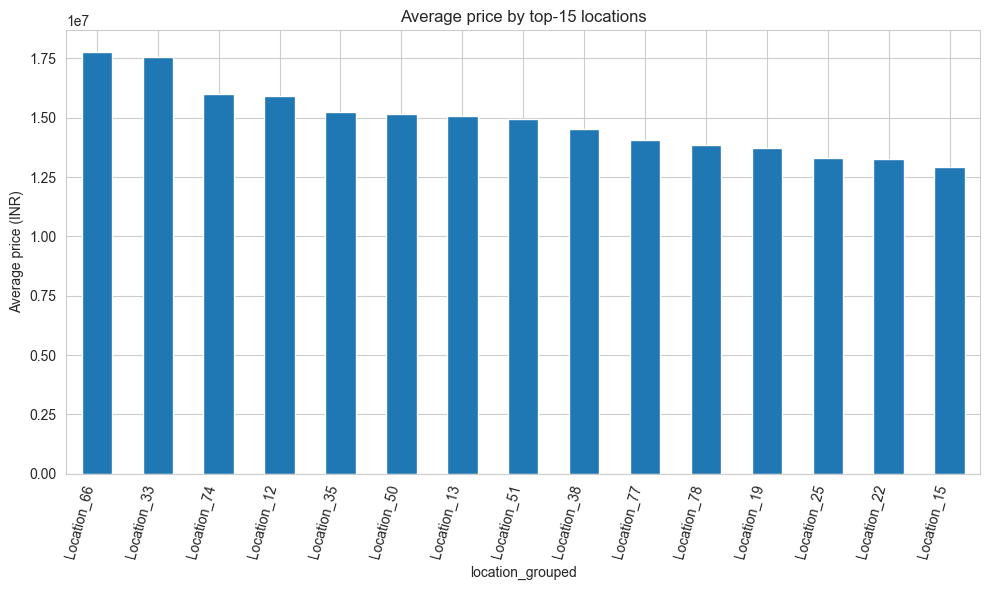

In [18]:
# Plot 3 — Average price by top-15 locations
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
top15.plot(kind="bar")
plt.title("Average price by top-15 locations")
plt.ylabel("Average price (INR)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

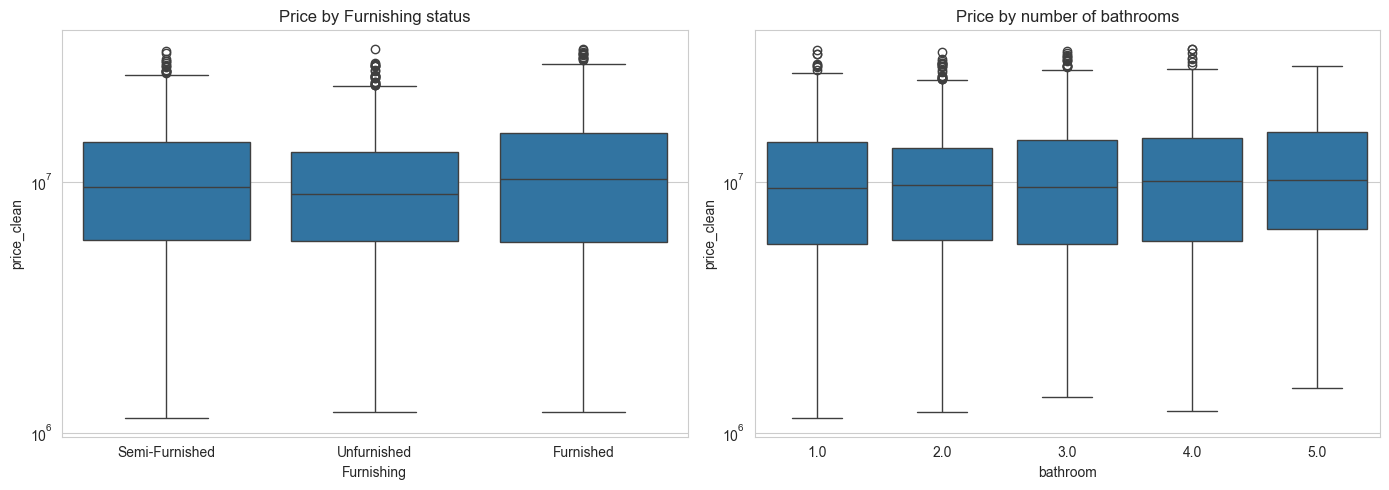

In [19]:
# Plot 4 — Price by furnishing status / bathrooms (box plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by Furnishing status")

sns.boxplot(data=df, x="bathroom", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

**Comment on each plot:**
- Plot 1: _(e.g. price is right-skewed, log scale makes it roughly normal...)_
- Plot 2: _(e.g. positive correlation between area and price, with some outliers...)_
- Plot 3: _(e.g. big spread between top locations, some clearly premium areas...)_
- Plot 4: _(e.g. furnished properties trend higher, more bathrooms correlates with higher price...)_


## 2.4 Build a Pipeline & Train

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

# Keep only columns that actually exist (dataset columns can vary — always verify!)
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((2880, 9), (720, 9))

In [21]:
# Baseline model
linreg = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression()),
])
linreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [22]:
# Stronger model
rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)),
])
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

**Bonus — log-transform target:** because price is skewed, training on `np.log1p(y)` and
inverting with `np.expm1` at prediction time often improves results. Try it below and compare.


In [23]:
rf_log = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)),
])
rf_log.fit(X_train, np.log1p(y_train))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

## 2.5 Evaluate

In [24]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(name, model, X_test, y_test, log_target=False):
    pred = model.predict(X_test)
    if log_target:
        pred = np.expm1(pred)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

results = [
    evaluate("LinearRegression", linreg, X_test, y_test),
    evaluate("RandomForest", rf, X_test, y_test),
    evaluate("RandomForest (log target)", rf_log, X_test, y_test, log_target=True),
]

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
1,RandomForest,2.098808e+06,2.799569e+06,0.799258
0,LinearRegression,2.103187e+06,2.807976e+06,0.798050
2,RandomForest (log target),2.233269e+06,3.006527e+06,0.768481


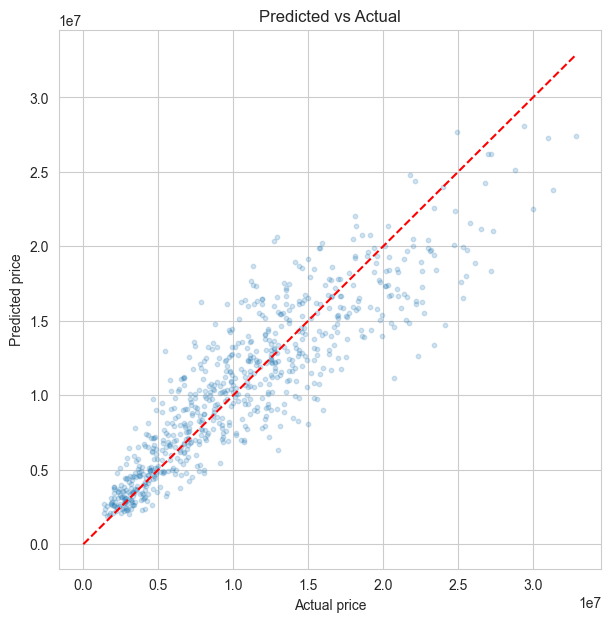

In [25]:
# Predicted vs actual scatter for the best model (adjust if a different model wins)
best_pred = rf.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.2, s=10)
lims = [0, max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual")
plt.show()

In [26]:
# Bonus — 5-fold cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="neg_root_mean_squared_error")
print("CV RMSE:", -cv_scores.mean(), "+/-", cv_scores.std())

CV RMSE: 3066884.166050695 +/- 138134.15002423697


**Conclusion:** _(write one paragraph justifying which model you're picking as the final one,
based on the comparison table above — usually the one with the lowest RMSE / highest R² on the test set.)_


## 2.6 Export the Model

In [27]:
import joblib

# Pick your winning pipeline — change this if a different model performed better
final_model = rf

joblib.dump(final_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [11825750.]


In [28]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w"),
)

In [29]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt")

scikit-learn version: 1.9.0
Pin this exact version in backend/requirements.txt
